# Phase Oracle

#### The phase oracle Uf acts as |x> --> (-1)^f(x) |x>

#### Consider f(x) = x

In [4]:
import qiskit
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [ ]:
# Phase oracle for f(x) = x using an ancilla prepared in |->
# U_f acts as |x>|-> --> (-1)^{f(x)} |x>|-> where f(x)=x



# Build the oracle gate: for f(x)=x it's simply a CNOT (control=input qubit, target=ancilla)
oracle = QuantumCircuit(2, name='U_f')
oracle.cx(0, 1)
U_f = oracle.to_gate()
U_f.label = 'U_f'

# Construct a test circuit:
# - qubit 0: input x (we'll put it in superposition with H)
# - qubit 1: ancilla prepared in |-> (X then H)
# After applying U_f the phase (-1)^{f(x)} will be applied to the input basis states.
# To observe the phase, perform an H on the input qubit (interference) then measure.
qc = QuantumCircuit(2, 1)  # one classical bit to read the input qubit

# Prepare input in superposition
qc.h(0)

# Prepare ancilla in |->: X then H yields |->
qc.x(1)
qc.h(1)

# Apply the phase oracle
qc.append(U_f, [0, 1])

# Convert phase into amplitude on input qubit and measure
#qc.h(0)
qc.measure(0, 0)

# Draw circuit (optional in notebook)
print(qc.draw())


     ┌───┐     ┌──────┐┌─┐
q_0: ┤ H ├─────┤0     ├┤M├
     ├───┤┌───┐│  U_f │└╥┘
q_1: ┤ X ├┤ H ├┤1     ├─╫─
     └───┘└───┘└──────┘ ║ 
c: 1/═══════════════════╩═
                        0 


Simulation counts for qc (phase oracle f(x)=x): {'0': 497, '1': 503}


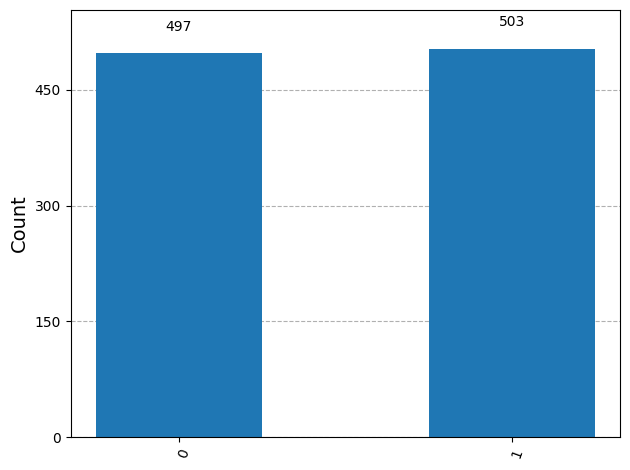

In [13]:
# Simulate
sim = AerSimulator()
qc_compiled = transpile(qc, sim)
job = sim.run(qc_compiled, shots=1000)
result = job.result()
counts = result.get_counts()

print('Simulation counts for qc (phase oracle f(x)=x):', counts)
plot_histogram(counts)